<a href="https://colab.research.google.com/github/serghino/MGL869-01-2026-mining-challenge/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Étape 1: Installation des bibliothèques d'analyse de sentiment

In [2]:
# Installation des bibliothèques nécessaires
!pip install vaderSentiment textblob nltk pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.1 MB/s eta 0:00:00


## Étape 2: Imports et configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import nltk

# Télécharger les ressources NLTK nécessaires
nltk.download('punkt')
nltk.download('brown')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


## Étape 3: Chargement des données

In [4]:
# Chargement des datasets
pr_comments_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_comments.parquet")
pr_reviews_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_reviews.parquet")
pr_review_comments_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_review_comments_v2.parquet")

# Charger les PRs (pour identifier AI vs Human)
pull_request_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")

print(f"Nombre de commentaires PR: {len(pr_comments_df)}")
print(f"Nombre de reviews: {len(pr_reviews_df)}")
print(f"Nombre de commentaires de review: {len(pr_review_comments_df)}")
print(f"Nombre de PRs: {len(pull_request_df)}")

Nombre de commentaires PR: 39122
Nombre de reviews: 28875
Nombre de commentaires de review: 26868
Nombre de PRs: 33596


Etape 3.1: Il n'y a pas ni de commentaires ni de reviews realisés par des humains par rapport aux pull requests creés par des humains.

In [5]:
# Human-PR
human_pr_df = pd.read_parquet("hf://datasets/hao-li/AIDev/human_pull_request.parquet")

# Merge human PRs with comments
human_pr_with_comments = human_pr_df.merge(
    pr_comments_df,
    left_on='id',
    right_on='pr_id',
    how='inner',
    suffixes=('_pr', '_comment')
)
print(f"Nombre de commentaires sur les PRs humains: {len(human_pr_with_comments)}")

# Merge human PRs with reviews
human_pr_with_reviews = human_pr_df.merge(
    pr_reviews_df,
    left_on='id',
    right_on='pr_id',
    how='inner',
    suffixes=('_pr', '_review')
)
print(f"Nombre de reviews sur les PRs humains: {len(human_pr_with_reviews)}")

Nombre de commentaires sur les PRs humains: 0
Nombre de reviews sur les PRs humains: 0


In [7]:
# 1. Définir les bots automatisés à exclure (pas des agents IA de code)
automated_bots = [
    'github-advanced-security[bot]',            # Security scanning
    'sourcery-ai[bot]',                         # Code quality refactoring
    'github-actions[bot]',                      # CI/CD automation
    'graphite-app[bot]',                        # Git workflow tool
    'qodo-merge-pro[bot]',                      # PR merge automation
    'qodo-merge-for-open-source[bot]',          # PR merge automation
    'codescene-delta-analysis[bot]',            # Code analysis
    'hound[bot]',                               # Code review style checker
    'pullrequest[bot]',                         # PR automation
    'codefactor-io[bot]',                       # Code quality
    'matter-code-review[bot]',                  # Code review automation
    'seer-by-sentry[bot]',                      # Error monitoring
    'aikido-pr-checks[bot]',                    # Security checks
    'semgrep-code-getsentry[bot]',              # Static analysis
    'semgrep-code-assistant-ws[bot]',           # Static analysis
    'semgrep-code-zeta-chain[bot]',             # Static analysis
    'starrocks-cr[bot]',                        # Code review
    'recurseml[bot]',                           # ML automation
    'vercel[bot]',                              # Deployment
    'propel-code-bot[bot]',                     # Code automation
]

# 2. Identifier les reviews faites par des humains (User)
human_reviews = pr_reviews_df[pr_reviews_df['user_type'] == 'User']

# 3. Identifier les bots et séparer les agents IA des bots automatisés
bot_reviews = pr_reviews_df[pr_reviews_df['user_type'] == 'Bot']

# Vérifier les noms de bots qui existent réellement dans les données
print("Noms de bots uniques dans les données:")
print(bot_reviews['user'].unique())
print(f"\nNombre total de reviews par bot: {len(bot_reviews)}")

ai_agent_reviews = bot_reviews[~bot_reviews['user'].isin(automated_bots)]
automated_bot_reviews = bot_reviews[bot_reviews['user'].isin(automated_bots)]

# 4. Joindre avec les PRs pour avoir les infos de l'agent
prs_with_human_reviewers = pull_request_df.merge(
    human_reviews[['pr_id', 'user', 'user_type', 'state', 'body']],
    left_on='id',
    right_on='pr_id',
    how='inner',
    suffixes=('_pr', '_review')
)

prs_with_ai_agent_reviewers = pull_request_df.merge(
    ai_agent_reviews[['pr_id', 'user', 'user_type', 'state', 'body']],
    left_on='id',
    right_on='pr_id',
    how='inner',
    suffixes=('_pr', '_review')
)

print(f"Nombre de PRs avec au moins un reviewer humain (sans bots auto): {prs_with_human_reviewers['id'].nunique()}")
print(f"Nombre de PRs avec au moins un reviewer agent IA: {prs_with_ai_agent_reviewers['id'].nunique()}")

# 5. Identifier les PRs qui ont à la fois des reviewers humains ET des agents IA
human_pr_ids = set(prs_with_human_reviewers['id'].unique())
ai_agent_pr_ids = set(prs_with_ai_agent_reviewers['id'].unique())
both_reviewers_pr_ids = human_pr_ids.intersection(ai_agent_pr_ids)

print(f"\nNombre de PRs avec à la fois des reviewers humains ET agents IA: {len(both_reviewers_pr_ids)}")

# 6. Créer les datasets pour l'analyse de sentiment
# PRs reviewés SEULEMENT par des humains (sans agents IA)
prs_only_human = prs_with_human_reviewers[~prs_with_human_reviewers['id'].isin(both_reviewers_pr_ids)]

# PRs reviewés SEULEMENT par des agents IA (sans humains)
prs_only_ai = prs_with_ai_agent_reviewers[~prs_with_ai_agent_reviewers['id'].isin(both_reviewers_pr_ids)]

print(f"\n=== Datasets pour analyse de sentiment ===")
print(f"PRs reviewés UNIQUEMENT par des humains: {prs_only_human['id'].nunique()}")
print(f"PRs reviewés UNIQUEMENT par des agents IA: {prs_only_ai['id'].nunique()}")
print(f"PRs reviewés par les DEUX: {len(both_reviewers_pr_ids)}")

print(f"\n=== Distribution des agents IA (PRs uniquement IA) ===")
print(prs_only_ai.groupby('agent')['id'].nunique())

# Les commentaires à analyser pour le sentiment
print(f"\n=== Commentaires pour analyse ===")
print(f"Nombre de commentaires humains (PRs uniquement humains): {len(prs_only_human)}")
print(f"Nombre de commentaires IA (PRs uniquement IA): {len(prs_only_ai)}")

# 7. Explorer les commentaires
# D'abord voir les colonnes disponibles
print(f"\n=== Colonnes disponibles ===")
print(prs_only_human.columns.tolist())

# Vérifier les commentaires non vides
print(f"\n=== Statistiques sur les commentaires ===")
print(f"Commentaires humains non vides: {prs_only_human['body_review'].notna().sum()}")
print(f"Commentaires IA non vides: {prs_only_ai['body_review'].notna().sum()}")

Noms de bots uniques dans les données:
['coderabbitai[bot]' 'ellipsis-dev[bot]'
 'copilot-pull-request-reviewer[bot]' 'gemini-code-assist[bot]'
 'cursor[bot]' 'github-advanced-security[bot]' 'cubic-dev-ai[bot]'
 'greptile-apps[bot]' 'sourcery-ai[bot]' 'github-actions[bot]'
 'graphite-app[bot]' 'claude[bot]' 'windsurf-bot[bot]'
 'copilot-swe-agent[bot]' 'qodo-merge-pro[bot]'
 'codescene-delta-analysis[bot]' 'hound[bot]' 'pullrequest[bot]'
 'qodo-merge-for-open-source[bot]' 'codefactor-io[bot]' 'kodus-ai[bot]'
 'dust-agent[bot]' 'codeant-ai[bot]' 'giselles-ai[bot]'
 'charliecreates[bot]' 'wispbit-ai[bot]' 'matter-code-review[bot]'
 'seer-by-sentry[bot]' 'aikido-pr-checks[bot]'
 'semgrep-code-getsentry[bot]' 'starrocks-cr[bot]' 'recurseml[bot]'
 'korbit-ai[bot]' 'entelligence-ai-pr-reviews[bot]' 'agent-optibot[bot]'
 'semgrep-code-assistant-ws[bot]' 'amazon-q-developer[bot]' 'vercel[bot]'
 'callstackai[bot]' 'semgrep-code-zeta-chain[bot]' 'propel-code-bot[bot]']

Nombre total de reviews p

In [57]:
# 8. Appliquer la même approche pour pr_comments (commentaires de ligne de code)
# Identifier les commentaires par type d'utilisateur
human_comments = pr_comments_df[pr_comments_df['user_type'] == 'User']
bot_comments = pr_comments_df[pr_comments_df['user_type'] == 'Bot']
ai_agent_comments = bot_comments[~bot_comments['user'].isin(automated_bots)]
automated_bot_comments = bot_comments[bot_comments['user'].isin(automated_bots)]

# Joindre avec les PRs
prs_with_human_comments = pull_request_df.merge(
    human_comments[['pr_id', 'user', 'user_type', 'body']],
    left_on='id',
    right_on='pr_id',
    how='inner',
    suffixes=('_pr', '_comment')
)

prs_with_ai_agent_comments = pull_request_df.merge(
    ai_agent_comments[['pr_id', 'user', 'user_type', 'body']],
    left_on='id',
    right_on='pr_id',
    how='inner',
    suffixes=('_pr', '_comment')
)

# Identifier les PRs avec les deux types
human_comment_pr_ids = set(prs_with_human_comments['id'].unique())
ai_agent_comment_pr_ids = set(prs_with_ai_agent_comments['id'].unique())
both_comments_pr_ids = human_comment_pr_ids.intersection(ai_agent_comment_pr_ids)

# PRs avec commentaires UNIQUEMENT humains ou IA
prs_comments_only_human = prs_with_human_comments[~prs_with_human_comments['id'].isin(both_comments_pr_ids)]
prs_comments_only_ai = prs_with_ai_agent_comments[~prs_with_ai_agent_comments['id'].isin(both_comments_pr_ids)]

print(f"\n=== Datasets PR Comments pour analyse de sentiment ===")
print(f"PRs avec commentaires UNIQUEMENT par des humains: {prs_comments_only_human['id'].nunique()}")
print(f"PRs avec commentaires UNIQUEMENT par des agents IA: {prs_comments_only_ai['id'].nunique()}")
print(f"PRs avec commentaires par les DEUX: {len(both_comments_pr_ids)}")

print(f"\n=== Statistiques sur les PR comments ===")
print(f"PR comments humains non vides: {prs_comments_only_human['body_comment'].notna().sum()}")
print(f"PR comments IA non vides: {prs_comments_only_ai['body_comment'].notna().sum()}")


=== Datasets PR Comments pour analyse de sentiment ===
PRs avec commentaires UNIQUEMENT par des humains: 1598
PRs avec commentaires UNIQUEMENT par des agents IA: 6519
PRs avec commentaires par les DEUX: 3752

=== Statistiques sur les PR comments ===
PR comments humains non vides: 2566
PR comments IA non vides: 11221


## Étape 4: Fonctions d'analyse de sentiment

Nous utilisons deux approches complémentaires:

### 1. VADER (Valence Aware Dictionary and sEntiment Reasoner)
- Optimisé pour les textes courts et informels (comme les commentaires GitHub)
- Retourne 4 scores: négatif, neutre, positif, et composé
- Le score composé varie de -1 (très négatif) à +1 (très positif)

### 2. TextBlob
- Retourne la polarité (-1 à +1) et la subjectivité (0 à 1)
- Utile pour comparer avec VADER

In [ ]:
# Initialiser l'analyseur VADER
vader_analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment_vader(text):
    """
    Analyse le sentiment avec VADER.
    Retourne un dictionnaire avec les scores: neg, neu, pos, compound
    """
    if pd.isna(text) or text == "":
        return {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0}

    scores = vader_analyzer.polarity_scores(str(text))
    return scores

def analyze_sentiment_textblob(text):
    """
    Analyse le sentiment avec TextBlob.
    Retourne un dictionnaire avec polarity et subjectivity
    """
    if pd.isna(text) or text == "":
        return {'polarity': 0, 'subjectivity': 0}

    blob = TextBlob(str(text))
    return {
        'polarity': blob.sentiment.polarity,
        'subjectivity': blob.sentiment.subjectivity
    }

def categorize_sentiment(compound_score):
    """
    Catégorise le sentiment selon le score composé VADER:
    - Positif: >= 0.05
    - Neutre: entre -0.05 et 0.05
    - Négatif: <= -0.05
    """
    if compound_score >= 0.05:
        return 'positif'
    elif compound_score <= -0.05:
        return 'négatif'
    else:
        return 'neutre'

print("✓ Fonctions d'analyse de sentiment définies")

✓ Fonctions d'analyse de sentiment définies


## Étape 5: Test des fonctions avec des exemples

In [ ]:
# Exemples de commentaires pour tester
test_comments = [
    "Great job! This code is excellent and well-documented.",
    "This is terrible code. Please fix it immediately.",
    "The implementation looks correct. Added some minor suggestions.",
    "LGTM! Thanks for the contribution 👍",
    "This breaks the entire application. Did you even test this?"
]

print("="*80)
print("TESTS D'ANALYSE DE SENTIMENT")
print("="*80)

for i, comment in enumerate(test_comments, 1):
    vader_scores = analyze_sentiment_vader(comment)
    textblob_scores = analyze_sentiment_textblob(comment)
    category = categorize_sentiment(vader_scores['compound'])

    print(f"\n{i}. Commentaire: \"{comment}\"")
    print(f"   VADER Compound: {vader_scores['compound']:.3f} (neg={vader_scores['neg']:.2f}, neu={vader_scores['neu']:.2f}, pos={vader_scores['pos']:.2f})")
    print(f"   TextBlob Polarity: {textblob_scores['polarity']:.3f}, Subjectivity: {textblob_scores['subjectivity']:.3f}")
    print(f"   → Catégorie: {category.upper()}")

TESTS D'ANALYSE DE SENTIMENT

1. Commentaire: "Great job! This code is excellent and well-documented."
   VADER Compound: 0.844 (neg=0.00, neu=0.43, pos=0.57)
   TextBlob Polarity: 1.000, Subjectivity: 0.875
   → Catégorie: POSITIF

2. Commentaire: "This is terrible code. Please fix it immediately."
   VADER Compound: -0.202 (neg=0.27, neu=0.53, pos=0.20)
   TextBlob Polarity: -1.000, Subjectivity: 1.000
   → Catégorie: NÉGATIF

3. Commentaire: "The implementation looks correct. Added some minor suggestions."
   VADER Compound: 0.000 (neg=0.00, neu=1.00, pos=0.00)
   TextBlob Polarity: -0.050, Subjectivity: 0.200
   → Catégorie: NEUTRE

4. Commentaire: "LGTM! Thanks for the contribution 👍"
   VADER Compound: 0.493 (neg=0.00, neu=0.65, pos=0.35)
   TextBlob Polarity: 0.200, Subjectivity: 0.200
   → Catégorie: POSITIF

5. Commentaire: "This breaks the entire application. Did you even test this?"
   VADER Compound: 0.000 (neg=0.00, neu=1.00, pos=0.00)
   TextBlob Polarity: 0.000, Subjecti

## Étape 7: Appliquer l'analyse de sentiment aux commentaires

Nous allons analyser tous les types de commentaires:
1. **pr_comments**: Commentaires généraux sur la PR
2. **pr_reviews**: Reviews complètes
3. **pr_review_comments**: Commentaires inline sur le code

In [ ]:
def add_sentiment_analysis(df, text_column='body'):
    """
    Ajoute les colonnes d'analyse de sentiment à un DataFrame.
    """
    print(f"Analyse de {len(df)} commentaires...")

    # Analyse VADER
    vader_results = df[text_column].apply(analyze_sentiment_vader)
    df['vader_neg'] = vader_results.apply(lambda x: x['neg'])
    df['vader_neu'] = vader_results.apply(lambda x: x['neu'])
    df['vader_pos'] = vader_results.apply(lambda x: x['pos'])
    df['vader_compound'] = vader_results.apply(lambda x: x['compound'])

    # Analyse TextBlob
    textblob_results = df[text_column].apply(analyze_sentiment_textblob)
    df['textblob_polarity'] = textblob_results.apply(lambda x: x['polarity'])
    df['textblob_subjectivity'] = textblob_results.apply(lambda x: x['subjectivity'])

    # Catégorisation
    df['sentiment_category'] = df['vader_compound'].apply(categorize_sentiment)

    print("✓ Analyse terminée")
    return df

# Note: L'exécution peut prendre quelques minutes selon la taille des datasets
print("Lancement de l'analyse des commentaires...")

# Analyse des commentaires de PR
print("\n1. Analyse des commentaires de PR (pr_comments)...")
pr_comments_with_sentiment = add_sentiment_analysis(pr_comments_df.copy())

# Analyse des reviews (si nécessaire, peut être long)
print("\n2. Analyse des reviews (pr_reviews)...")
pr_reviews_with_sentiment = add_sentiment_analysis(pr_reviews_df.copy())

# Analyse des commentaires de review (souvent le plus volumineux)
print("\n3. Analyse des commentaires de review (pr_review_comments)...")
pr_review_comments_with_sentiment = add_sentiment_analysis(pr_review_comments_df.copy())

print("\nAnalyse complète terminée !")

Lancement de l'analyse des commentaires...

1. Analyse des commentaires de PR (pr_comments)...
Analyse de 39122 commentaires...
✓ Analyse terminée

2. Analyse des reviews (pr_reviews)...
Analyse de 28875 commentaires...
✓ Analyse terminée

3. Analyse des commentaires de review (pr_review_comments)...
Analyse de 26868 commentaires...
✓ Analyse terminée

Analyse complète terminée !


## Étape 8: Analyse des résultats (utilisant les données de l'étape 7)

Nous analysons maintenant les résultats complets de l'analyse de sentiment effectuée à l'étape 7.

In [ ]:
# Utiliser les données complètes de l'étape 7
# On travaille directement avec les DataFrames qui ont déjà l'analyse de sentiment

print("="*80)
print("RÉSUMÉ DES SENTIMENTS - PR COMMENTS")
print("="*80)
print("\nDistribution des catégories de sentiment:")
print(pr_comments_with_sentiment['sentiment_category'].value_counts())
print(f"\nPourcentages:")
print(pr_comments_with_sentiment['sentiment_category'].value_counts(normalize=True) * 100)

print(f"\n\nStatistiques VADER Compound Score:")
print(pr_comments_with_sentiment['vader_compound'].describe())

print(f"\n\nStatistiques TextBlob Polarity:")
print(pr_comments_with_sentiment['textblob_polarity'].describe())

RÉSUMÉ DES SENTIMENTS - PR COMMENTS

Distribution des catégories de sentiment:
sentiment_category
positif    18591
négatif    12373
neutre      8158
Name: count, dtype: int64

Pourcentages:
sentiment_category
positif    47.520577
négatif    31.626706
neutre     20.852717
Name: proportion, dtype: float64


Statistiques VADER Compound Score:
count    39122.000000
mean         0.131276
std          0.528091
min         -1.000000
25%         -0.224400
50%          0.000000
75%          0.517400
max          1.000000
Name: vader_compound, dtype: float64


Statistiques TextBlob Polarity:
count    39122.000000
mean         0.059594
std          0.271272
min         -1.000000
25%          0.000000
50%          0.045455
75%          0.212121
max          1.000000
Name: textblob_polarity, dtype: float64


## Étape 9: Visualisation des résultats

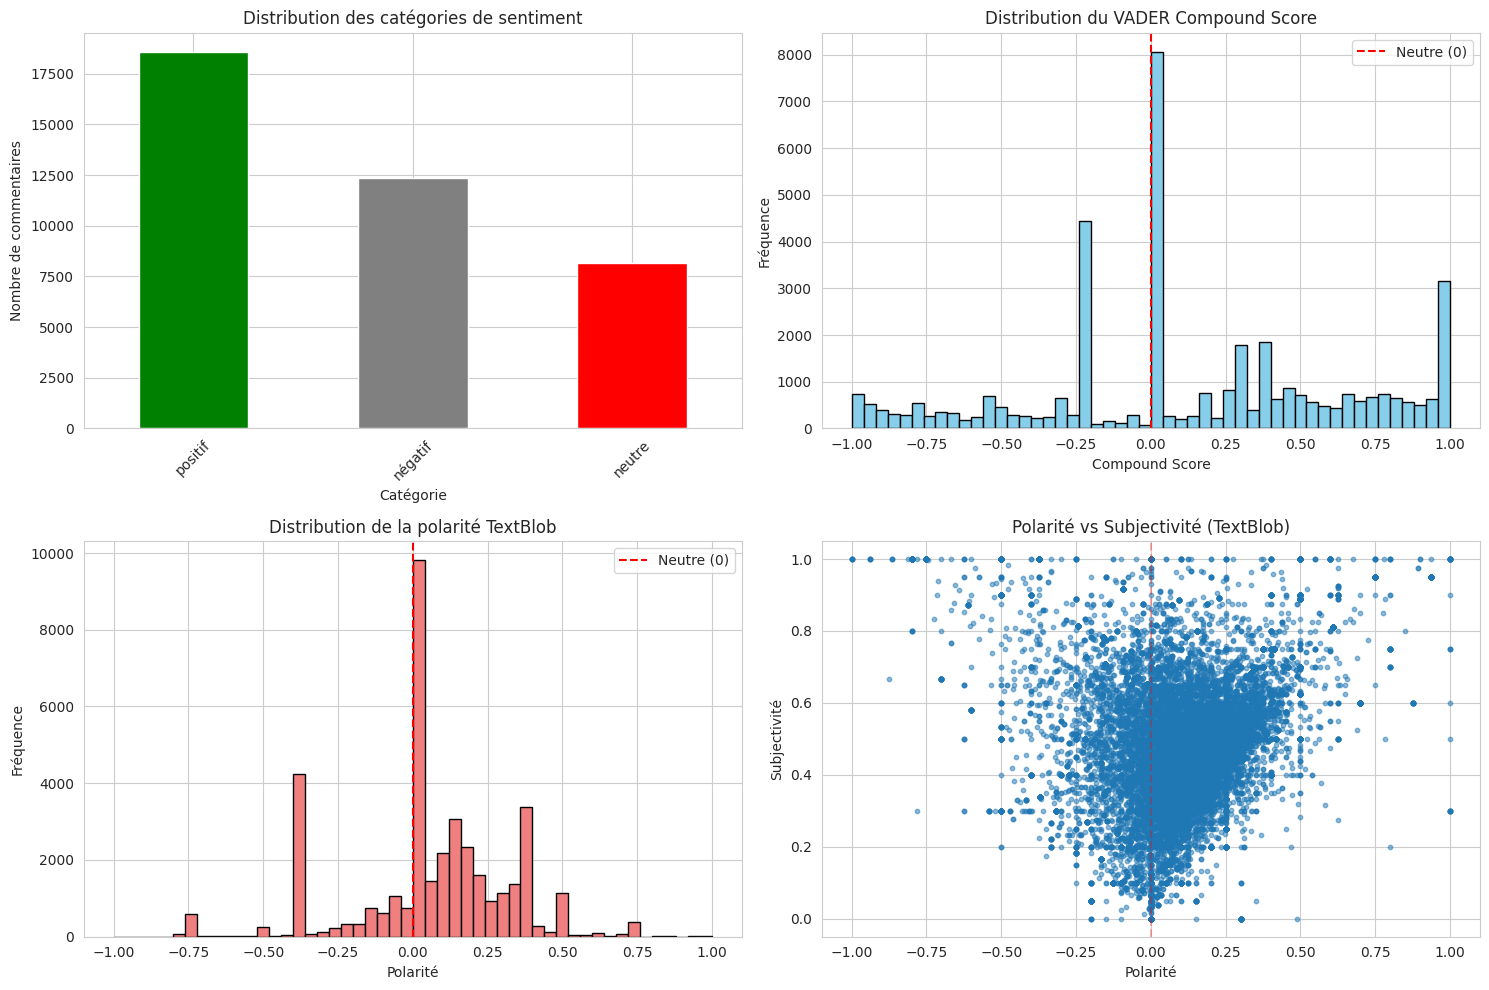


✓ Visualisations générées


In [ ]:
# Créer des visualisations à partir des données complètes de l'étape 7
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution des catégories de sentiment
pr_comments_with_sentiment['sentiment_category'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'gray', 'red'])
axes[0, 0].set_title('Distribution des catégories de sentiment')
axes[0, 0].set_xlabel('Catégorie')
axes[0, 0].set_ylabel('Nombre de commentaires')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Distribution du score VADER Compound
axes[0, 1].hist(pr_comments_with_sentiment['vader_compound'], bins=50, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Distribution du VADER Compound Score')
axes[0, 1].set_xlabel('Compound Score')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(x=0, color='red', linestyle='--', label='Neutre (0)')
axes[0, 1].legend()

# 3. Distribution de la polarité TextBlob
axes[1, 0].hist(pr_comments_with_sentiment['textblob_polarity'], bins=50, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Distribution de la polarité TextBlob')
axes[1, 0].set_xlabel('Polarité')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].axvline(x=0, color='red', linestyle='--', label='Neutre (0)')
axes[1, 0].legend()

# 4. Relation entre polarité et subjectivité
axes[1, 1].scatter(pr_comments_with_sentiment['textblob_polarity'],
                   pr_comments_with_sentiment['textblob_subjectivity'],
                   alpha=0.5, s=10)
axes[1, 1].set_title('Polarité vs Subjectivité (TextBlob)')
axes[1, 1].set_xlabel('Polarité')
axes[1, 1].set_ylabel('Subjectivité')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualisations générées")

## Étape 10: Exemples de commentaires par catégorie

In [ ]:
def show_examples_by_sentiment(df, n=3):
    """
    Affiche des exemples de commentaires pour chaque catégorie de sentiment.
    """
    for category in ['positif', 'neutre', 'négatif']:
        print(f"\n{'='*80}")
        print(f"EXEMPLES DE COMMENTAIRES {category.upper()}S")
        print(f"{'='*80}\n")

        examples = df[df['sentiment_category'] == category].nlargest(n, 'vader_compound' if category == 'positif' else 'vader_neg')

        for idx, row in examples.iterrows():
            print(f"Commentaire: {row['body'][:200]}..." if len(str(row['body'])) > 200 else f"Commentaire: {row['body']}")
            print(f"VADER Compound: {row['vader_compound']:.3f}")
            print(f"TextBlob Polarity: {row['textblob_polarity']:.3f}")
            print("-" * 80)

# Utiliser les données complètes de l'étape 7
show_examples_by_sentiment(pr_comments_with_sentiment, n=3)


EXEMPLES DE COMMENTAIRES POSITIFS

Commentaire: Please supply an indication of how this update should be tested in app. 
Running `flutter analyze` returns a whole lot which I'm guessing does not relate to a +3/-1 commit.

<details>
  <summary>`...
VADER Compound: 1.000
TextBlob Polarity: 0.083
--------------------------------------------------------------------------------
Commentaire: <!-- This is an auto-generated reply by CodeRabbit -->
> [!TIP]
> For best results, initiate chat on the files or code changes.

<details>
<summary>🧩 Analysis chain</summary>

@wtfsayo I'll conduct a ...
VADER Compound: 1.000
TextBlob Polarity: 0.317
--------------------------------------------------------------------------------
Commentaire: # Stats from current PR

<details open>
<summary><strong>Default Build</strong> (Increase detected ⚠️)</summary>

<br/>

<details>
<summary><strong>General</strong> Overall increase ⚠️</summary>

|  |...
VADER Compound: 1.000
TextBlob Polarity: -0.163
-------------

## Étape 11: Analyse Bot vs User Comments

**Note importante**: Tous les PRs dans le dataset sont créés par des agents IA.
Cependant, les **commentaires** sur ces PRs peuvent être faits par:
- **Bot** (user_type = 'Bot'): Commentaires automatisés
- **User** (user_type = 'User'): Commentaires humains

Nous allons comparer le sentiment des commentaires Bot vs User.

## Diagnostic: Vérification de la colonne 'user_type'

Vérifions la distribution Bot vs User dans les commentaires.

In [ ]:
# Vérifier la distribution des commentaires par type d'utilisateur
print("="*80)
print("ANALYSE DE LA COLONNE 'user_type' dans pr_comments_with_sentiment")
print("="*80)

print("\nDistribution des commentaires par user_type:")
print(pr_comments_with_sentiment['user_type'].value_counts())

print("\nPourcentages:")
print(pr_comments_with_sentiment['user_type'].value_counts(normalize=True) * 100)

print("\n\nExemples de commentaires Bot:")
print(pr_comments_with_sentiment[pr_comments_with_sentiment['user_type'] == 'Bot'][['body', 'user_type']].head(3))

print("\n\nExemples de commentaires User:")
print(pr_comments_with_sentiment[pr_comments_with_sentiment['user_type'] == 'User'][['body', 'user_type']].head(3))

print("\n\nLongueur moyenne des commentaires par type:")
pr_comments_with_sentiment['text_length'] = pr_comments_with_sentiment['body'].apply(
    lambda x: len(str(x).split())
)
print(pr_comments_with_sentiment.groupby('user_type')['text_length'].mean())

ANALYSE DE LA COLONNE 'user_type' dans pr_comments_with_sentiment

Distribution des commentaires par user_type:
user_type
Bot     27416
User    11706
Name: count, dtype: int64

Pourcentages:
user_type
Bot     70.078217
User    29.921783
Name: proportion, dtype: float64


Exemples de commentaires Bot:
                                                                                                  body  \
0  <!-- This is an auto-generated comment: summarize by coderabbit.ai -->\n<!-- walkthrough_start -...   
3  ## Deploying instructor-py with &nbsp;<a href="https://pages.dev"><img alt="Cloudflare Pages" sr...   
5  [vc]: #G27wnP3o1yHCleMvCyJPjlwd7awIyVdXK+zxkgAkIWM=:eyJpc01vbm9yZXBvIjp0cnVlLCJ0eXBlIjoiZ2l0aHVi...   

  user_type  
0       Bot  
3       Bot  
5       Bot  


Exemples de commentaires User:
                                                                                                body  \
1           claude budget reached, development is on hold for now.\r\nEDIT: we a

In [ ]:
# Utiliser directement pr_comments_with_sentiment qui a déjà user_type et l'analyse de sentiment
# Pas besoin de fusion avec pull_request_df

print("="*80)
print("PRÉPARATION DES DONNÉES POUR L'ANALYSE")
print("="*80)

# Vérifier qu'on a bien les deux types
bot_count = (pr_comments_with_sentiment['user_type'] == 'Bot').sum()
user_count = (pr_comments_with_sentiment['user_type'] == 'User').sum()

print(f"\nTotal commentaires: {len(pr_comments_with_sentiment)}")
print(f"Commentaires Bot: {bot_count}")
print(f"Commentaires User (Humains): {user_count}")

# Filtrer pour avoir seulement Bot et User
analysis_df = pr_comments_with_sentiment[
    pr_comments_with_sentiment['user_type'].isin(['Bot', 'User'])
].copy()

print(f"\nCommentaires retenus pour l'analyse: {len(analysis_df)}")
print(f"Distribution:")
print(analysis_df['user_type'].value_counts())

PRÉPARATION DES DONNÉES POUR L'ANALYSE

Total commentaires: 39122
Commentaires Bot: 27416
Commentaires User (Humains): 11706

Commentaires retenus pour l'analyse: 39122
Distribution:
user_type
Bot     27416
User    11706
Name: count, dtype: int64


## Étape 12: Analyse comparative du sentiment (Bot vs User)

Nous allons maintenant comparer les scores de sentiment entre:
- **Bot comments**: Commentaires automatisés
- **User comments**: Commentaires humains

In [ ]:
# Utiliser analysis_df de l'étape 11 qui contient les données filtrées

# Créer un échantillon stratifié si nécessaire
SAMPLE_SIZE = 10000

bot_count = (analysis_df['user_type'] == 'Bot').sum()
user_count = (analysis_df['user_type'] == 'User').sum()

print(f"Distribution complète:")
print(f"Total commentaires: {len(analysis_df)}")
print(f"- Commentaires Bot: {bot_count}")
print(f"- Commentaires User: {user_count}")

# Échantillonnage stratifié si le dataset est trop grand
if len(analysis_df) > SAMPLE_SIZE:
    sample_per_group = SAMPLE_SIZE // 2

    bot_sample = analysis_df[analysis_df['user_type'] == 'Bot'].sample(
        n=min(sample_per_group, bot_count), random_state=42
    )
    user_sample = analysis_df[analysis_df['user_type'] == 'User'].sample(
        n=min(sample_per_group, user_count), random_state=42
    )

    sampled_df = pd.concat([bot_sample, user_sample], ignore_index=True)
else:
    sampled_df = analysis_df.copy()

# Séparer les groupes pour l'analyse
bot_comments = sampled_df[sampled_df['user_type'] == 'Bot']
user_comments = sampled_df[sampled_df['user_type'] == 'User']

print(f"\n{'='*80}")
print(f"ÉCHANTILLON D'ANALYSE")
print(f"{'='*80}")
print(f"Taille de l'échantillon analysé: {len(sampled_df)}")
print(f"- Commentaires Bot: {len(bot_comments)}")
print(f"- Commentaires User: {len(user_comments)}")

# Statistiques descriptives
print(f"\n{'='*80}")
print(f"STATISTIQUES DESCRIPTIVES")
print(f"{'='*80}")

print("\n--- Commentaires BOT ---")
print(f"Score VADER moyen: {bot_comments['vader_compound'].mean():.4f}")
print(f"Score VADER médian: {bot_comments['vader_compound'].median():.4f}")
print(f"Score VADER std: {bot_comments['vader_compound'].std():.4f}")
print("\nDistribution des catégories:")
print(bot_comments['sentiment_category'].value_counts())

print("\n--- Commentaires USER (Humains) ---")
print(f"Score VADER moyen: {user_comments['vader_compound'].mean():.4f}")
print(f"Score VADER médian: {user_comments['vader_compound'].median():.4f}")
print(f"Score VADER std: {user_comments['vader_compound'].std():.4f}")
print("\nDistribution des catégories:")
print(user_comments['sentiment_category'].value_counts())

print("\n✓ Données prêtes pour le test d'hypothèse")

Distribution complète:
Total commentaires: 39122
- Commentaires Bot: 27416
- Commentaires User: 11706

ÉCHANTILLON D'ANALYSE
Taille de l'échantillon analysé: 10000
- Commentaires Bot: 5000
- Commentaires User: 5000

STATISTIQUES DESCRIPTIVES

--- Commentaires BOT ---
Score VADER moyen: 0.1434
Score VADER médian: 0.0772
Score VADER std: 0.5641

Distribution des catégories:
sentiment_category
positif    2526
négatif    1808
neutre      666
Name: count, dtype: int64

--- Commentaires USER (Humains) ---
Score VADER moyen: 0.1000
Score VADER médian: 0.0000
Score VADER std: 0.4494

Distribution des catégories:
sentiment_category
positif    1966
neutre     1954
négatif    1080
Name: count, dtype: int64

✓ Données prêtes pour le test d'hypothèse


## Étape 13: Test d'Hypothèse (H0 vs H1)

**H0**: Pas de différence significative de ton entre commentaires Bot et User.
**H1**: Ton différent entre les commentaires automatisés (Bot) et humains (User).

Nous utiliserons le test de Mann-Whitney U car les scores de sentiment ne suivent généralement pas une distribution normale.

TEST D'HYPOTHÈSE: BOT vs USER COMMENTS

Score moyen VADER (Compound) - Bot: 0.1434
Score moyen VADER (Compound) - User: 0.1000
Différence: 0.0433

Résultats du test Mann-Whitney U:
Statistique U: 13052765.50
P-value: 0.000113

Tests de normalité (Shapiro-Wilk):
Bot p-value: 0.000000
User p-value: 0.000000

CONCLUSION
✓ Rejet de l'hypothèse nulle (H0) avec α = 0.05
  P-value (0.000113) < 0.05

→ Les commentaires BOT sont significativement PLUS POSITIFS
  Différence: 0.0433 (43.3%)


/tmp/ipython-input-3041540784.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_type', y='vader_compound', data=sampled_df, ax=axes[0], palette=['lightcoral', 'lightblue'])


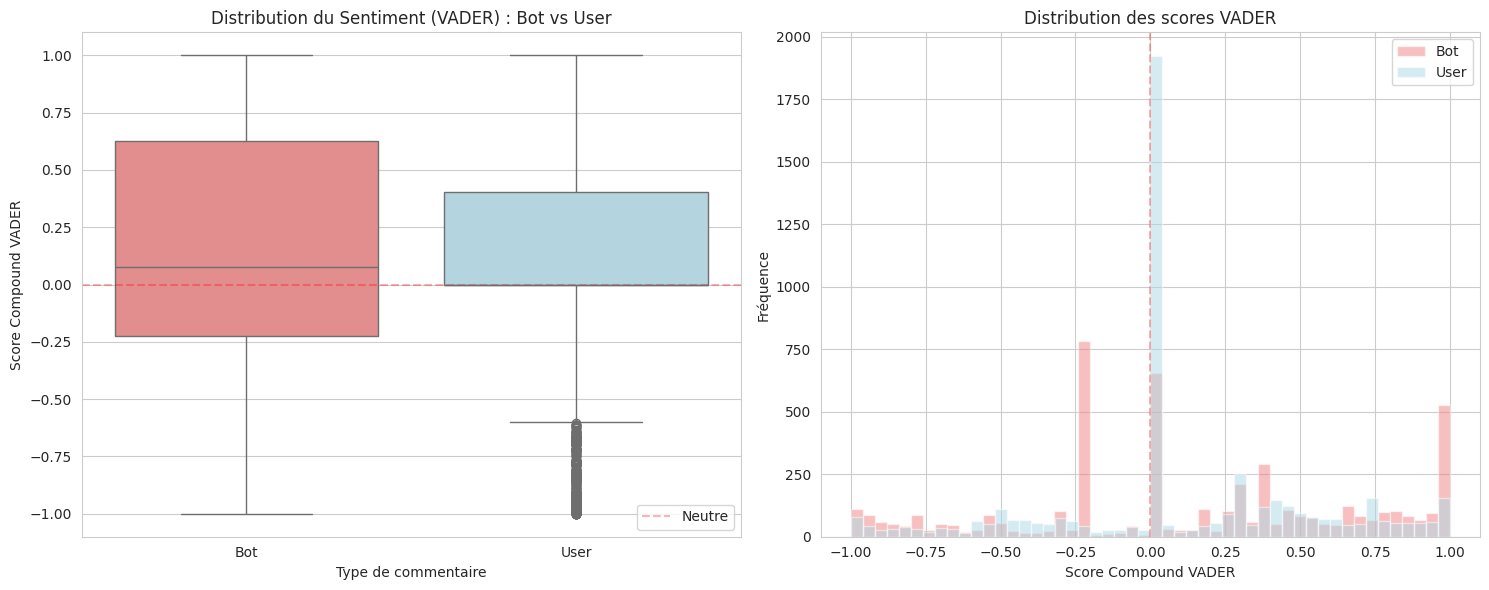


✓ Visualisations générées


In [ ]:
from scipy import stats

# Calcul des moyennes
mean_bot = bot_comments['vader_compound'].mean()
mean_user = user_comments['vader_compound'].mean()

print("="*80)
print("TEST D'HYPOTHÈSE: BOT vs USER COMMENTS")
print("="*80)

print(f"\nScore moyen VADER (Compound) - Bot: {mean_bot:.4f}")
print(f"Score moyen VADER (Compound) - User: {mean_user:.4f}")
print(f"Différence: {mean_bot - mean_user:.4f}")

# Test statistique (Mann-Whitney U)
stat, p_value = stats.mannwhitneyu(
    bot_comments['vader_compound'],
    user_comments['vader_compound'],
    alternative='two-sided'
)

print(f"\nRésultats du test Mann-Whitney U:")
print(f"Statistique U: {stat:.2f}")
print(f"P-value: {p_value:.6f}")

# Test de normalité (pour information)
from scipy.stats import shapiro
_, p_bot = shapiro(bot_comments['vader_compound'].sample(min(5000, len(bot_comments))))
_, p_user = shapiro(user_comments['vader_compound'].sample(min(5000, len(user_comments))))
print(f"\nTests de normalité (Shapiro-Wilk):")
print(f"Bot p-value: {p_bot:.6f}")
print(f"User p-value: {p_user:.6f}")

# Interprétation
alpha = 0.05
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

if p_value < alpha:
    print(f"✓ Rejet de l'hypothèse nulle (H0) avec α = {alpha}")
    print(f"  P-value ({p_value:.6f}) < {alpha}")

    if mean_bot > mean_user:
        diff_pct = ((mean_bot - mean_user) / abs(mean_user)) * 100
        print(f"\n→ Les commentaires BOT sont significativement PLUS POSITIFS")
        print(f"  Différence: {mean_bot - mean_user:.4f} ({diff_pct:.1f}%)")
    else:
        diff_pct = ((mean_user - mean_bot) / abs(mean_bot)) * 100
        print(f"\n→ Les commentaires USER (humains) sont significativement PLUS POSITIFS")
        print(f"  Différence: {mean_user - mean_bot:.4f} ({diff_pct:.1f}%)")
else:
    print(f"✗ Échec du rejet de l'hypothèse nulle (H0)")
    print(f"  P-value ({p_value:.6f}) ≥ {alpha}")
    print(f"\n→ Pas de différence significative détectée entre Bot et User")

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(x='user_type', y='vader_compound', data=sampled_df, ax=axes[0], palette=['lightcoral', 'lightblue'])
axes[0].set_title('Distribution du Sentiment (VADER) : Bot vs User')
axes[0].set_xlabel('Type de commentaire')
axes[0].set_ylabel('Score Compound VADER')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Neutre')
axes[0].legend()

# Histogrammes superposés
axes[1].hist(bot_comments['vader_compound'], bins=50, alpha=0.5, label='Bot', color='lightcoral')
axes[1].hist(user_comments['vader_compound'], bins=50, alpha=0.5, label='User', color='lightblue')
axes[1].set_title('Distribution des scores VADER')
axes[1].set_xlabel('Score Compound VADER')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n✓ Visualisations générées")